In [2]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import numpy as np  
sns.set()
%matplotlib inline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.cluster import KMeans
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [22]:
df =pd.read_csv("Preprocessed_Data (2).csv")
df.isna().sum()


Unnamed: 0             0
track_id               0
artists                0
album_name             0
track_name             0
popularity             0
duration_ms            0
explicit               0
danceability           0
energy                 0
key                    0
loudness               0
mode                   0
speechiness            0
acousticness           0
instrumentalness       0
liveness               0
valence                0
tempo                  0
time_signature         0
track_genre            0
energy_dance_ratio     0
acoustic_electronic    0
log_duration_ms        0
artists_freq           0
track_genre_encoded    0
popularity_bin         0
dtype: int64

In [17]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre', 'energy_dance_ratio', 'acoustic_electronic',
       'log_duration_ms', 'artists_freq', 'track_genre_encoded',
       'popularity_bin'],
      dtype='object')

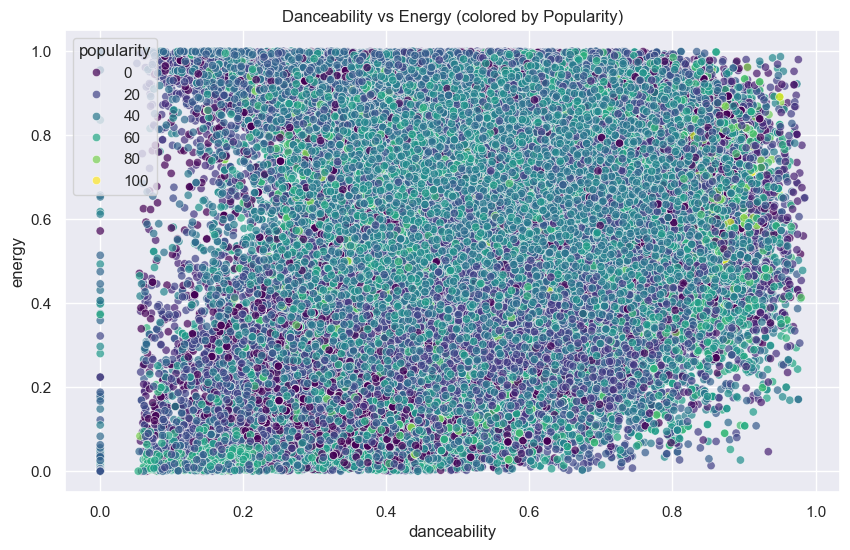

In [19]:
# Scatter: Danceability vs Energy (colored by popularity)
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='danceability', y='energy', hue='popularity', 
                palette='viridis', alpha=0.7)
plt.title('Danceability vs Energy (colored by Popularity)')


In [35]:
corr_matrix=df.corr

Not enough numerical columns for correlation analysis


In [26]:
df.columns

Index(['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name',
       'popularity', 'duration_ms', 'explicit', 'danceability', 'energy',
       'key', 'loudness', 'mode', 'speechiness', 'acousticness',
       'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature',
       'track_genre', 'energy_dance_ratio', 'acoustic_electronic',
       'log_duration_ms', 'artists_freq', 'track_genre_encoded',
       'popularity_bin'],
      dtype='object')

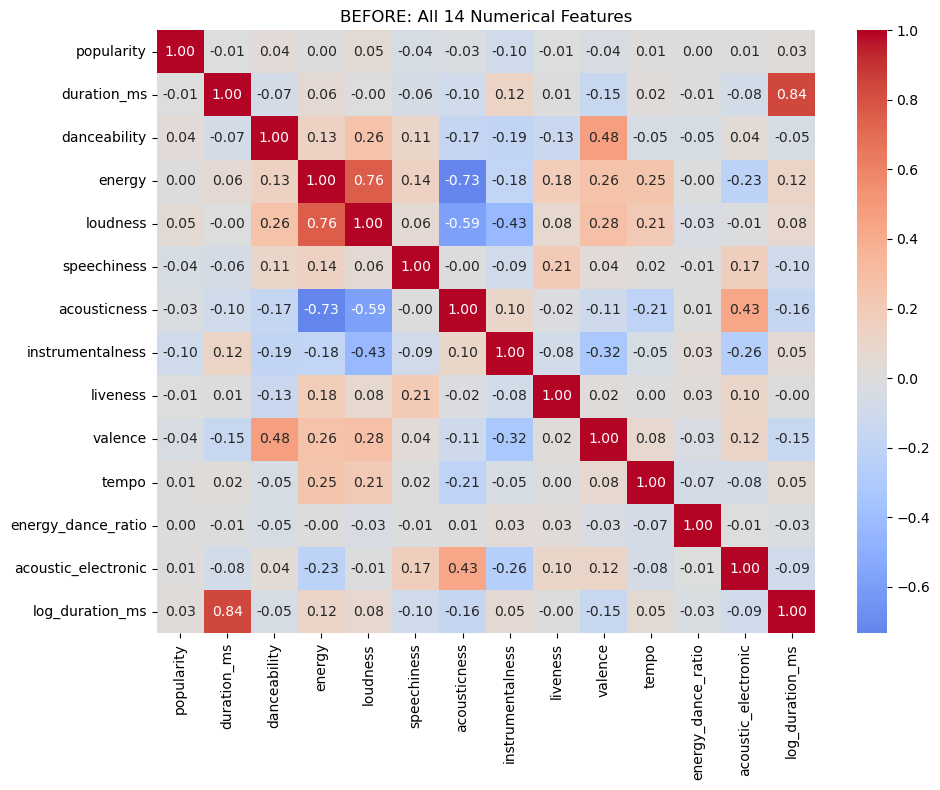

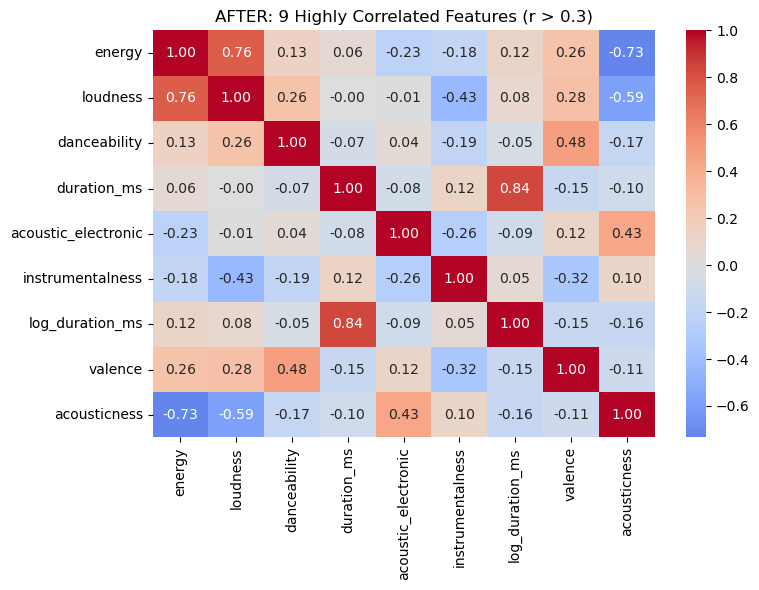

Kept 9 highly correlated features:
['energy', 'loudness', 'danceability', 'duration_ms', 'acoustic_electronic', 'instrumentalness', 'log_duration_ms', 'valence', 'acousticness']


In [36]:
# Simple version - keep only features with high correlations
def simple_keep_high_corr(df, threshold=0.3):
    """Simple function to keep only highly correlated features"""
    
    numerical_features = [col for col in ['popularity', 'duration_ms', 'danceability', 'energy', 
                         'loudness', 'speechiness', 'acousticness', 'instrumentalness', 
                         'liveness', 'valence', 'tempo', 'energy_dance_ratio', 
                         'acoustic_electronic', 'log_duration_ms'] if col in df.columns]
    
    # BEFORE heatmap
    plt.figure(figsize=(10, 8))
    sns.heatmap(df[numerical_features].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
    plt.title(f'BEFORE: All {len(numerical_features)} Numerical Features')
    plt.tight_layout()
    plt.show()
    
    # Find highly correlated features
    corr_matrix = df[numerical_features].corr().abs()
    high_corr_features = set()
    
    for i in range(len(corr_matrix.columns)):
        for j in range(i+1, len(corr_matrix.columns)):
            if corr_matrix.iloc[i, j] > threshold:
                high_corr_features.add(corr_matrix.columns[i])
                high_corr_features.add(corr_matrix.columns[j])
    
    high_corr_features = list(high_corr_features)
    
    # AFTER heatmap
    if len(high_corr_features) > 1:
        plt.figure(figsize=(8, 6))
        sns.heatmap(df[high_corr_features].corr(), annot=True, cmap='coolwarm', center=0, fmt=".2f")
        plt.title(f'AFTER: {len(high_corr_features)} Highly Correlated Features (r > {threshold})')
        plt.tight_layout()
        plt.show()
    
    print(f"Kept {len(high_corr_features)} highly correlated features:")
    print(high_corr_features)
    
    return df[high_corr_features]

# Run the simple version
df_final = simple_keep_high_corr(df, threshold=0.3)

In [42]:
categorical_columns = df.select_dtypes(include=['object', 'category']).columns.tolist()

categorical_columns


['track_id', 'artists', 'album_name', 'track_name', 'track_genre']

In [44]:
for i in categorical_columns:
    df_final[i]=df[i]
df_final

C:\Users\hp\AppData\Local\Temp\ipykernel_20956\1258961231.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[i]=df[i]
C:\Users\hp\AppData\Local\Temp\ipykernel_20956\1258961231.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_final[i]=df[i]
C:\Users\hp\AppData\Local\Temp\ipykernel_20956\1258961231.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https

,energy,loudness,danceability,duration_ms,acoustic_electronic,instrumentalness,log_duration_ms,valence,acousticness,track_id,artists,album_name,track_name,track_genre
0,0.4610,-6.746,0.676,230666,16019.900498,0.000001,12.348730,0.7150,0.0322,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,acoustic
1,0.1660,-17.235,0.420,149610,140853.658537,0.000006,11.915794,0.2670,0.9240,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,acoustic
2,0.3590,-9.734,0.438,210826,210000.000000,0.000000,12.258793,0.1200,0.2100,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,acoustic
3,0.0596,-18.515,0.266,201933,12622.036262,0.000071,12.215696,0.1430,0.9050,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,acoustic
4,0.4430,-9.681,0.618,198853,469000.000000,0.000000,12.200326,0.1670,0.4690,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113994,0.2350,-16.393,0.172,384999,0.689654,0.928000,12.860999,0.0339,0.6400,2C3TZjDRiAzdyViavDJ217,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Sleep My Little Boy,world-music
113995,0.1170,-18.318,0.174,385000,1.018442,0.976000,12.861001,0.0350,0.9940,1hIz5L4IB9hN3WRYPOCGPw,Rainy Lullaby,#mindfulness - Soft Rain for Mindful Meditatio...,Water Into Light,world-music
113996,0.3290,-10.895,0.629,271466,867000.000000,0.000000,12.511596,0.7430,0.8670,6x8ZfSoqDjuNa5SVP5QjvX,Cesária Evora,Best Of,Miss Perfumado,world-music
113997,0.5060,-10.889,0.587,283893,381000.000000,0.000000,12.556356,0.4130,0.3810,2e6sXL2bYv4bSz6VTdnfLs,Michael W. Smith,Change Your World,Friends,world-music


In [73]:
# Get numerical columns (make sure this is defined)
numerical_cols = df_final.select_dtypes(include=[np.number]).columns.tolist()

print(f"Applying IQR outlier removal on {len(numerical_cols)} numerical columns...")

masks = []
for column in numerical_cols:
    Q1 = df_final[column].quantile(0.25)
    Q3 = df_final[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Create mask for this column (True = keep, False = outlier)
    mask = (df_final[column] >= lower_bound) & (df_final[column] <= upper_bound)
    masks.append(mask)
    
    # Optional: Print bounds for each column
    print(f"{column}: Q1={Q1:.2f}, Q3={Q3:.2f}, IQR={IQR:.2f}, Bounds=[{lower_bound:.2f}, {upper_bound:.2f}]")

# Combine masks: keep row only if it's within bounds for ALL columns
overall_mask = pd.concat(masks, axis=1).all(axis=1)

# Apply the combined mask
df_final1 = df_final[overall_mask]

print(f"\nOutlier removal complete!")
print(f"Original shape: {df_final.shape}")
print(f"New shape: {df_final1.shape}")
print(f"Rows removed: {len(df_final) - len(df_final1)}")
print(f"Percentage kept: {(len(df_final1)/len(df_final))*100:.1f}%")

Applying IQR outlier removal on 9 numerical columns...
energy: Q1=0.47, Q3=0.85, IQR=0.38, Bounds=[-0.10, 1.43]
loudness: Q1=-10.01, Q3=-5.00, IQR=5.01, Bounds=[-17.53, 2.51]
danceability: Q1=0.46, Q3=0.69, IQR=0.24, Bounds=[0.10, 1.05]
duration_ms: Q1=174066.00, Q3=261506.00, IQR=87440.00, Bounds=[42906.00, 392666.00]
acoustic_electronic: Q1=1.11, Q3=110000.00, IQR=109998.89, Bounds=[-164997.24, 274998.34]
instrumentalness: Q1=0.00, Q3=0.05, IQR=0.05, Bounds=[-0.07, 0.12]
log_duration_ms: Q1=12.07, Q3=12.47, IQR=0.41, Bounds=[11.46, 13.08]
valence: Q1=0.26, Q3=0.68, IQR=0.42, Bounds=[-0.37, 1.32]
acousticness: Q1=0.02, Q3=0.60, IQR=0.58, Bounds=[-0.85, 1.47]

Outlier removal complete!
Original shape: (113999, 14)
New shape: (66589, 14)
Rows removed: 47410
Percentage kept: 58.4%


In [75]:
df_final1

,energy,loudness,danceability,duration_ms,acoustic_electronic,instrumentalness,log_duration_ms,valence,acousticness,track_id,artists,album_name,track_name,track_genre
0,0.461,-6.746,0.676,230666,16019.900498,0.000001,12.348730,0.7150,0.032200,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,acoustic
1,0.166,-17.235,0.420,149610,140853.658537,0.000006,11.915794,0.2670,0.924000,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,acoustic
2,0.359,-9.734,0.438,210826,210000.000000,0.000000,12.258793,0.1200,0.210000,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,acoustic
6,0.147,-8.822,0.407,229400,220308.483290,0.000003,12.343227,0.0765,0.857000,6Vc5wAMmXdKIAM7WUoEb7N,A Great Big World;Christina Aguilera,Is There Anybody Out There?,Say Something,acoustic
9,0.632,-6.770,0.442,205594,101.646385,0.004190,12.233663,0.1960,0.426000,7k9GuJYLp2AzqokyEdwEw2,Ross Copperman,Hunger,Hunger,acoustic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
113986,0.938,-4.722,0.470,246306,529.000000,0.000000,12.414334,0.4530,0.000529,4jDhzTYkEG5GloIWwVeVkc,Planetshakers,Revival (Live),All My Life - Live,world-music
113990,0.531,-4.788,0.387,250629,3050.000000,0.000000,12.431733,0.1530,0.003050,0CE0Y6GM75cbrqao8EOAlW,Chris Tomlin,The Ultimate Playlist,At The Cross (Love Ran Red),world-music
113991,0.860,-4.722,0.475,312566,2389.705882,0.000002,12.652574,0.4270,0.006500,3FjOBB4EyIXHYUtSgrIdY9,Jesus Culture,Revelation Songs,Your Love Never Fails,world-music
113992,0.687,-4.375,0.505,256026,84100.000000,0.000000,12.453038,0.3820,0.084100,4OkMK49i3NApR1KsAIsTf6,Chris Tomlin,See The Morning (Special Edition),How Can I Keep From Singing,world-music


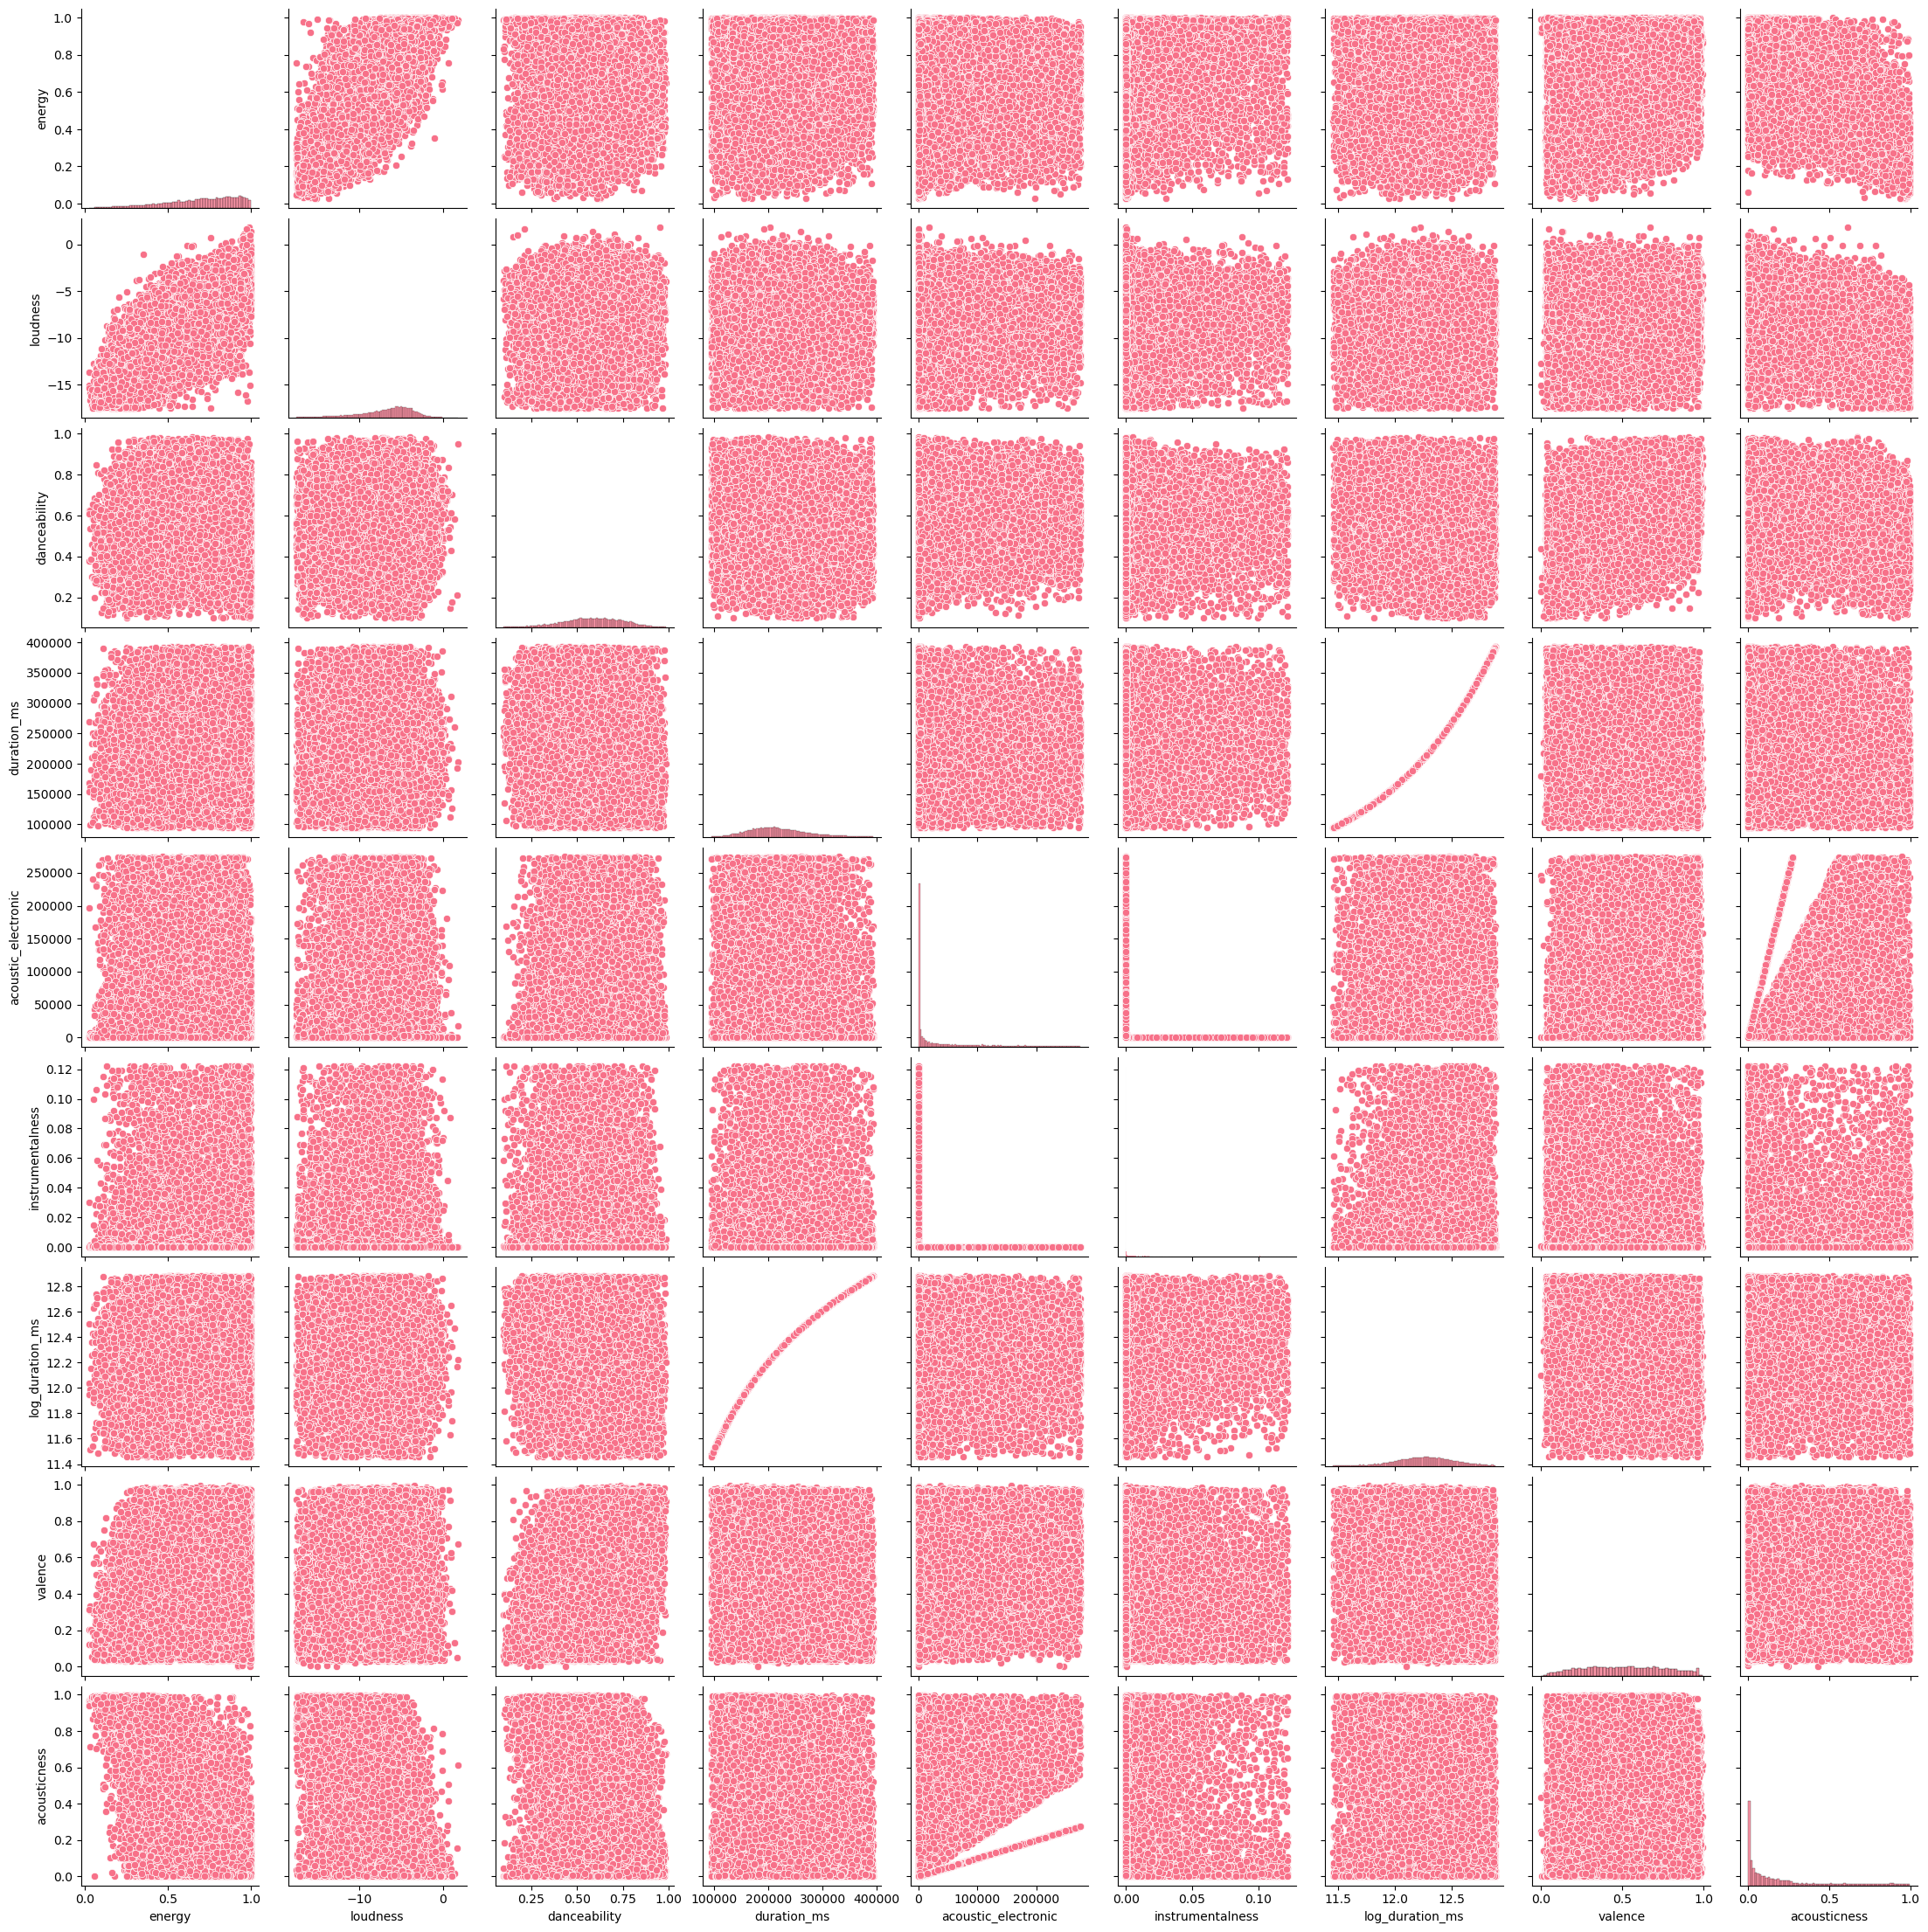

In [81]:
sns.pairplot(df_final1)

In [93]:

# Your data info
numerical_cols = ['energy', 'loudness', 'danceability', 'duration_ms', 
                  'acoustic_electronic', 'instrumentalness', 'log_duration_ms', 
                  'valence', 'acousticness']
categorical_cols = ['track_id', 'artists', 'album_name', 'track_name', 'track_genre']

print(f"Original shape: {df_final1.shape}")
print(f"Numerical columns: {len(numerical_cols)}")
print(f"Categorical columns: {len(categorical_cols)}")

# Preprocess categorical data with CountVectorizer
def preprocess_categorical_vectorizer(df, categorical_cols, max_features=1000):
    """Use CountVectorizer for categorical text data"""
    processed_features = []
    
    for col in categorical_cols:
        # Convert to string and fill NaN
        text_data = df[col].fillna('unknown').astype(str)
        
        # Use CountVectorizer
        vectorizer = CountVectorizer(max_features=max_features, 
                                   lowercase=True, 
                                   token_pattern=r'(?u)\b\w+\b')
        vectorized = vectorizer.fit_transform(text_data)
        
        # Convert to DataFrame
        feature_names = [f"{col}_{name}" for name in vectorizer.get_feature_names_out()]
        vec_df = pd.DataFrame(vectorized.toarray(), columns=feature_names, index=df.index)
        processed_features.append(vec_df)
        
        print(f"  {col}: {len(vectorizer.get_feature_names_out())} features")
    
    return pd.concat(processed_features, axis=1)

# Process categorical data with vectorizer
print("Processing categorical data with CountVectorizer...")
categorical_processed = preprocess_categorical_vectorizer(df_final1, categorical_cols, max_features=500)

# Process numerical data
print("Processing numerical data...")
scaler = StandardScaler()
numerical_processed = pd.DataFrame(
    scaler.fit_transform(df_final1[numerical_cols]),
    columns=numerical_cols,
    index=df_final1.index
)

# Combine all features
X_processed = pd.concat([numerical_processed, categorical_processed], axis=1)

print(f"Final processed shape: {X_processed.shape}")
print(f"Total features: {X_processed.shape[1]}")

Original shape: (66589, 14)
Numerical columns: 9
Categorical columns: 5
Processing categorical data with CountVectorizer...
  track_id: 500 features
  artists: 500 features
  album_name: 500 features
  track_name: 500 features
  track_genre: 119 features
Processing numerical data...
Final processed shape: (66589, 2128)
Total features: 2128


In [ ]:
def find_optimal_k_elbow(X, max_k=17):
    """Find optimal k using elbow method with detailed analysis"""
    inertias = []
    k_range = range(1, max_k + 1)
    
    print("Calculating inertias for different k values...")
    for k in k_range:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10, max_iter=300)
        kmeans.fit(X)
        inertias.append(kmeans.inertia_)
        print(f"  k={k:2d}, inertia={kmeans.inertia_:.2f}")
    
    return inertias, k_range

# Find optimal k
inertias, k_range = find_optimal_k_elbow(X_processed, max_k=7)

# Plot elbow curve
plt.figure(figsize=(12, 6))
plt.plot(k_range, inertias, 'bo-', markersize=8, linewidth=2, label='Inertia')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True, alpha=0.3)
plt.xticks(k_range)

# Find elbow point automatically
def find_elbow_point(inertias, k_range):
    """Automatically find the elbow point"""
    # Calculate second differences
    first_diff = np.diff(inertias)
    second_diff = np.diff(first_diff)
    
    # Find point of maximum curvature
    elbow_index = np.argmax(np.abs(second_diff)) + 2
    optimal_k = min(elbow_index, len(k_range))
    
    return optimal_k

optimal_k = find_elbow_point(inertias, k_range)
plt.axvline(x=optimal_k, color='red', linestyle='--', alpha=0.7, 
            label=f'Optimal k={optimal_k}')
plt.legend()
plt.show()

print(f"Optimal number of clusters: {optimal_k}")

